In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal'})

In [9]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
SPLIT     = 'valid'

# Predictors to show: listed in display order (2 rows x 3 cols)
PREDICTORS = [
    ('rh',         True,  'RH (%)'),
    ('thetae',     True,  '$\\mathit{\\theta_{e}}$ (K)'),
    ('thetaestar', True,  '$\\mathit{\\theta_{e}}^*$ (K)'),
    ('lf',         False, 'LF'),
    ('shf',        False, 'SHF (W/m$^2$)'),
    ('lhf',        False, 'LHF (W/m$^2$)'),
]  # (varname, has_sig_dim, xlabel)

_MODELS  = CONFIGS['experiments']
MODELS_8 = ['pod_bl',
            # 'nn_bl',
            # 'nn_full',
            # 'nn_nonparam',
            # 'nn_gauss',
            'sr_lo','sr_med','sr_hi']
LABELS_8 = {}
for _name,_rc in _MODELS['pod']['runs'].items():
    LABELS_8[_name] = _rc.get('description',_name)
# for _name,_rc in _MODELS['nn']['runs'].items():
#     LABELS_8[_name] = _rc.get('description',_name)
for _name,_eqspec in _MODELS['sr'].get('optimizedeqs',{}).items():
    LABELS_8[_name] = _eqspec.get('description',_name)
# Color + linestyle per model (colors match pareto.ipynb)
STYLES = {
    'pod_bl':        ('#921519',  '-',  1.2),
    # 'nn_bl':         ('#fa862d',  '-',  1.2),
    # 'nn_full':       ('#1b2c63',  '-',  1.2),
    # 'nn_nonparam':   ('#245ba7',  '-',  1.2),
    # 'nn_gauss':      ('#5ca7db',  '-',  1.2),
    'sr_lo':         ('#c41d24',  '-',  1.2),
    'sr_med':        ('#fce998',  '-',  1.2),
    'sr_hi':         ('#a3ddf7',  '-',  1.2),
}
NBINS = 50

In [10]:
# Load stats for denormalization to native units
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    stats = json.load(f)

# Load normalized split for predictor values
with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    normds = {v:ds[v].load() for v in ds.data_vars}

# Build flat predictor arrays (time*lat*lon,) in native units
# For field variables with a vertical dimension we use a simple level mean
# (not kernel-integrated), then denormalize using training statistics.
ref_dims = ('time','lat','lon')
refshape = tuple(normds['tp'].sizes[d] for d in ref_dims)
refsize  = int(np.prod(refshape))

pred_flat = {}
for varname,has_sig,_ in PREDICTORS:
    if varname not in normds:
        print(f'Warning: {varname} not in norm split, skipping')
        continue
    da = normds[varname]
    if has_sig and 'sig' in da.dims:
        da = da.mean('sig')  # simple vertical mean, not kernel-integrated
    da    = da.transpose(*[d for d in ref_dims if d in da.dims])
    vmean = stats.get(f'{varname}_mean', 0.0)
    vstd  = stats.get(f'{varname}_std',  1.0)
    arr   = da.values.ravel()
    if arr.size == refsize:
        pred_flat[varname] = arr * vstd + vmean
    else:
        full = np.broadcast_to(da.values[...,np.newaxis] if 'lon' not in da.dims else da.values, refshape)
        pred_flat[varname] = full.ravel() * vstd + vmean

# Load observations
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()
true_flat = truetp.transpose(*ref_dims).values.ravel()

# Load predictions for each model
model_flat = {}
for name in MODELS_8:
    fpath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(fpath):
        print(f'Missing predictions: {name}')
        continue
    with xr.open_dataset(fpath) as ds:
        pred = ds.tp.load()
    if 'seed' in pred.dims:
        pred = pred.mean('seed')
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    _,pred = xr.align(truetp,pred,join='inner')
    model_flat[name] = pred.squeeze().transpose(*ref_dims).values.ravel()

valid_mask = np.isfinite(true_flat)
print(f'Valid samples: {valid_mask.sum():,}  |  Models loaded: {len(model_flat)}')

Valid samples: 1,437,408  |  Models loaded: 4


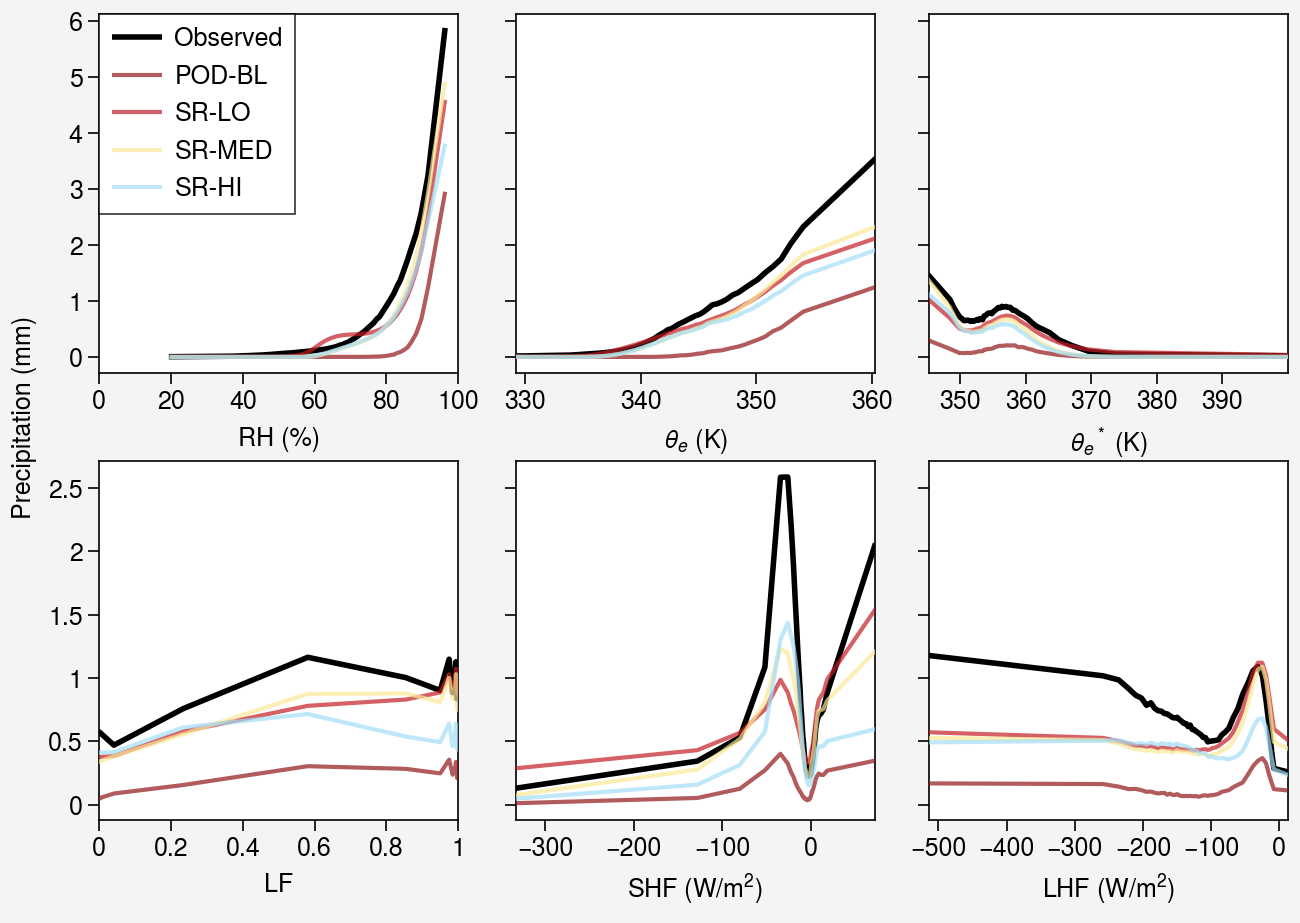

In [24]:
def bin_conditional(x_flat,y_flat,nbins=50):
    '''Bin y by quantiles of x; return (bin_centers, bin_means, bin_counts).'''
    finite    = np.isfinite(x_flat) & np.isfinite(y_flat)
    x,y       = x_flat[finite],y_flat[finite]
    edges     = np.quantile(x,np.linspace(0,1,nbins+1))
    centers   = 0.5*(edges[:-1]+edges[1:])
    means,counts = np.full(nbins,np.nan),np.zeros(nbins,dtype=int)
    for i in range(nbins):
        sel = (x >= edges[i]) & (x <= edges[i+1])
        if sel.sum() >= 5:
            means[i]  = y[sel].mean()
            counts[i] = sel.sum()
    return centers,means,counts

avail_preds = [(vn,has_sig,xl) for vn,has_sig,xl in PREDICTORS if vn in pred_flat]
fig,axs     = pplt.subplots(nrows=2,ncols=3,figwidth=6.5,sharex=False,spany=True,tight=True,hspace=3.5)
axs.format(grid=False,gridminor=False,ylabel='Precipitation (mm)')
axs = np.atleast_1d(axs).ravel()

for col,(varname,has_sig,xlabel) in enumerate(avail_preds):
    ax   = axs[col]
    xarr = pred_flat[varname]

    # Observed
    centers,obs_means,_ = bin_conditional(xarr,true_flat,NBINS)
    ax.plot(centers,obs_means,color='k',lw=2,ls='-',label='Observed',zorder=0)

    # Each model
    for name in MODELS_8:
        if name not in model_flat:
            continue
        color,ls,lw = STYLES[name]
        _,means,_   = bin_conditional(xarr,model_flat[name],NBINS)
        ax.plot(centers,means,color=color,ls=ls,lw=1.5,alpha=0.7,
                label=LABELS_8.get(name,name),zorder=5)

    ax.format(xlabel=xlabel,xminorticks='none',yminorticks='none')

axs[0].format(xlim=(0,100),xticks=20)
axs[1].format(xticks=10)
axs[2].format(xticks=10)
axs[3].format(xlim=(0,1),xticks=0.2)
axs[4].format(xticks=100)
axs[5].format(xticks=100)
axs[0].legend(loc='ul',ncols=1)
pplt.show()
fig.save('../figs/fig_2.jpg')